# Clasificación supervisada de abandono de clientes Telco

Este es un ejemplo elaborado para el curso de Inteligencia Artificial de la Universidad del Magdalena. El ejemplo busca mostrar el uso de algunas estrategias y métodos para inspeccionar y explorar los datos con el fin de detectar anomalías y determinar pasos necesarios para la preparación de los datos antes de aplicar métodos de aprendizaje supervisado.

El dataset Telco Customer Churn representa el problema de identificar clientes de una empresa de telecomunicaciones que podrían abandonar el servicio, fenómeno conocido como churn. Detectar este comportamiento es importante porque la pérdida de clientes afecta directamente los ingresos de la empresa y, en muchos casos, retener a un cliente existente resulta menos costoso que adquirir uno nuevo. A partir de información sobre los servicios contratados, características de la cuenta, permanencia y facturación, es posible analizar patrones asociados con el abandono.

Este ejemplo incluye:

- Inspección inicial de los datos
- Exploración y visualización
- limpieza y preparación

El dataset utilizado en este ejemplo lo pueden encontrar aquí:
https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data

## 1. Importación de librerías y configuración

Se utilizan herramientas de pandas y seaborn para inspección y exploración de los datos.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
#from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neural_network import MLPClassifier

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

## 2. Carga del dataset

Cada fila representa un cliente. Las columnas describen información demográfica, servicios contratados, antigüedad, facturación y abandono.

In [2]:
DATA_URL = ("https://raw.githubusercontent.com/aiplanethub/Datasets/master/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df_raw = pd.read_csv(DATA_URL)
df = df_raw.copy()

In [3]:
print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
df.info()
display(df.head())

Dimensiones: 7,043 filas x 21 columnas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Pap

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


La mayoría de las variables contenidas en el datase son de tipo object, en este caso representa variables de tipo categórico.

## 3. Inspección inicial

Antes de modificar los datos se revisan duplicados, identificadores, valores faltantes, tipos de datos y cardinalidad de las variables categóricas.

In [4]:
print("Duplicados completos:", df.duplicated().sum())
print("customerID únicos:", df["customerID"].nunique(), "de", len(df))

print("\nResumen de variables numéricas:")
display(df.describe().T)

print("\nResumen de variables de texto:")
display(df.describe(include="object").T)

Duplicados completos: 0
customerID únicos: 7043 de 7043

Resumen de variables numéricas:


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75



Resumen de variables de texto:


,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


Entre las variables numéricas se puede apreciar que la variable SeniorCitizen es una variable numérica que principalmente toma valores binarios. customerID contiene un valor único para cada ejemplo del dataset. La variable TotalCharges tiene una cardinalidad muy alta para ser una variable de tipo categórico.

### 3.1 Valores faltantes y cadenas vacías

`isna()` detecta valores faltantes explícitos. Sin embargo, algunos archivos CSV almacenan valores ausentes como cadenas vacías o espacios, por lo que también se revisan las columnas de texto.

In [5]:
missing_explicit = df.isna().sum().sort_values(ascending=False)
print("Faltantes explícitos detectados por isna():")
display(missing_explicit[missing_explicit > 0].to_frame("n_faltantes"))

object_cols_raw = df.select_dtypes(include="object").columns
blank_counts = {
    c: df[c].astype(str).str.strip().eq("").sum()
    for c in object_cols_raw
}
blank_counts = pd.Series(blank_counts).sort_values(ascending=False)

print("Cadenas vacías o espacios en variables de texto:")
display(blank_counts[blank_counts > 0].to_frame("n_vacios"))

Faltantes explícitos detectados por isna():


,n_faltantes


Cadenas vacías o espacios en variables de texto:


,n_vacios
TotalCharges,11


Como se puede observar no hay valores faltantes en el dataset; pero si hay algunas variables de tipo categórico con cadenas de espacios.

### 3.2 Cardinalidad de las variables categóricas

Esta inspección ayuda a detectar identificadores, variables casi constantes y categorías que posteriormente necesitarán codificación.

In [6]:
cat_summary = []

for c in object_cols_raw:
    cat_summary.append({
        "variable": c,
        "n_unicos": df[c].nunique(dropna=False),
        "ejemplos": list(df[c].drop_duplicates().astype(str).head(8))
    })

display(pd.DataFrame(cat_summary).sort_values("n_unicos", ascending=False))

,variable,n_unicos,ejemplos
0,customerID,7043,"[7590-VHVEG, 5575-GNVDE, 3668-QPYBK, 7795-CFOC..."
16,TotalCharges,6531,"[29.85, 1889.5, 108.15, 1840.75, 151.65, 820.5..."
15,PaymentMethod,4,"[Electronic check, Mailed check, Bank transfer..."
13,Contract,3,"[Month-to-month, One year, Two year]"
5,MultipleLines,3,"[No phone service, No, Yes]"
8,OnlineBackup,3,"[Yes, No, No internet service]"
9,DeviceProtection,3,"[No, Yes, No internet service]"
10,TechSupport,3,"[No, Yes, No internet service]"
7,OnlineSecurity,3,"[No, Yes, No internet service]"
6,InternetService,3,"[DSL, Fiber optic, No]"


Volvemos a ver que como variables categóricas las variables customerID y TotalCharges tiene una cardinalidad muy alta. En el caso de custormerID esto se debe a que esta variable representa un valor único para cada ejemplo, y en el caso de TotalCharges tenemos que la variable parece ser una variable de tipo numérico.

## 4. Limpieza de datos

`TotalCharges` aparece como texto porque contiene espacios en algunos registros. Primero se convierten esos espacios en valores faltantes y luego la columna se transforma a tipo numérico.

In [7]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].replace(r"^\s*$", np.nan, regex=True), errors="coerce")

print("TotalCharges faltantes después de la conversión:", df["TotalCharges"].isna().sum())

display(df.loc[df["TotalCharges"].isna(),
        ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]])

TotalCharges faltantes después de la conversión: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


### 4.1 Imputación basada en contexto

Antes de utilizar media o mediana se comprueba si los faltantes siguen una lógica del dominio. En este dataset, los registros con `TotalCharges` faltante corresponden a clientes con `tenure = 0`, es decir, clientes recién incorporados. En ese caso se asigna `TotalCharges = 0`.

In [8]:
mask_missing_total = df["TotalCharges"].isna()

if mask_missing_total.any() and df.loc[mask_missing_total, "tenure"].eq(0).all():
    df.loc[mask_missing_total, "TotalCharges"] = 0.0
    print("Imputación aplicada: TotalCharges = 0 para clientes con tenure = 0.")
elif mask_missing_total.any():
    mediana = df["TotalCharges"].median()
    df["TotalCharges"] = df["TotalCharges"].fillna(mediana)
    print(f"Imputación alternativa aplicada con mediana = {mediana:.2f}.")
else:
    print("No quedan faltantes en TotalCharges.")

Imputación aplicada: TotalCharges = 0 para clientes con tenure = 0.


### 4.2 Conversión de SeniorCitizen a variable categórica

`SeniorCitizen` está codificada con 0 y 1, pero conceptualmente representa una categoría y no una magnitud numérica. Se transforma a `No` y `Yes` para tratarla junto con las demás variables categóricas.

In [9]:
print("Tipo original:", df["SeniorCitizen"].dtype)
print("Valores originales:", df["SeniorCitizen"].unique())

# Se trata como variable categórica, no como magnitud numérica.
df["SeniorCitizen"] = df["SeniorCitizen"].replace({0: "No", 1: "Yes"})

print("Valores después de la conversión:", df["SeniorCitizen"].unique())

Tipo original: int64
Valores originales: [0 1]
Valores después de la conversión: ['No' 'Yes']


In [10]:
print("Faltantes restantes:", df.isna().sum().sum())
print("Duplicados restantes:", df.duplicated().sum())
df.info()

Faltantes restantes: 0
Duplicados restantes: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 


## 5. Análisis exploratorio

Se separan las variables numéricas y categóricas para estudiar sus distribuciones. La exploración permite detectar asimetrías, escalas diferentes, categorías dominantes y posibles relaciones entre variables.

In [11]:
TARGET = "Churn"
ID_COL = "customerID"

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
categorical_cols = [c for c in df.columns if c not in numeric_cols + [TARGET, ID_COL]]

print("Variables numéricas:", numeric_cols)
print("\nVariables categóricas:", categorical_cols)

Variables numéricas: ['tenure', 'MonthlyCharges', 'TotalCharges']

Variables categóricas: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### 5.1 Distribución de las variables numéricas

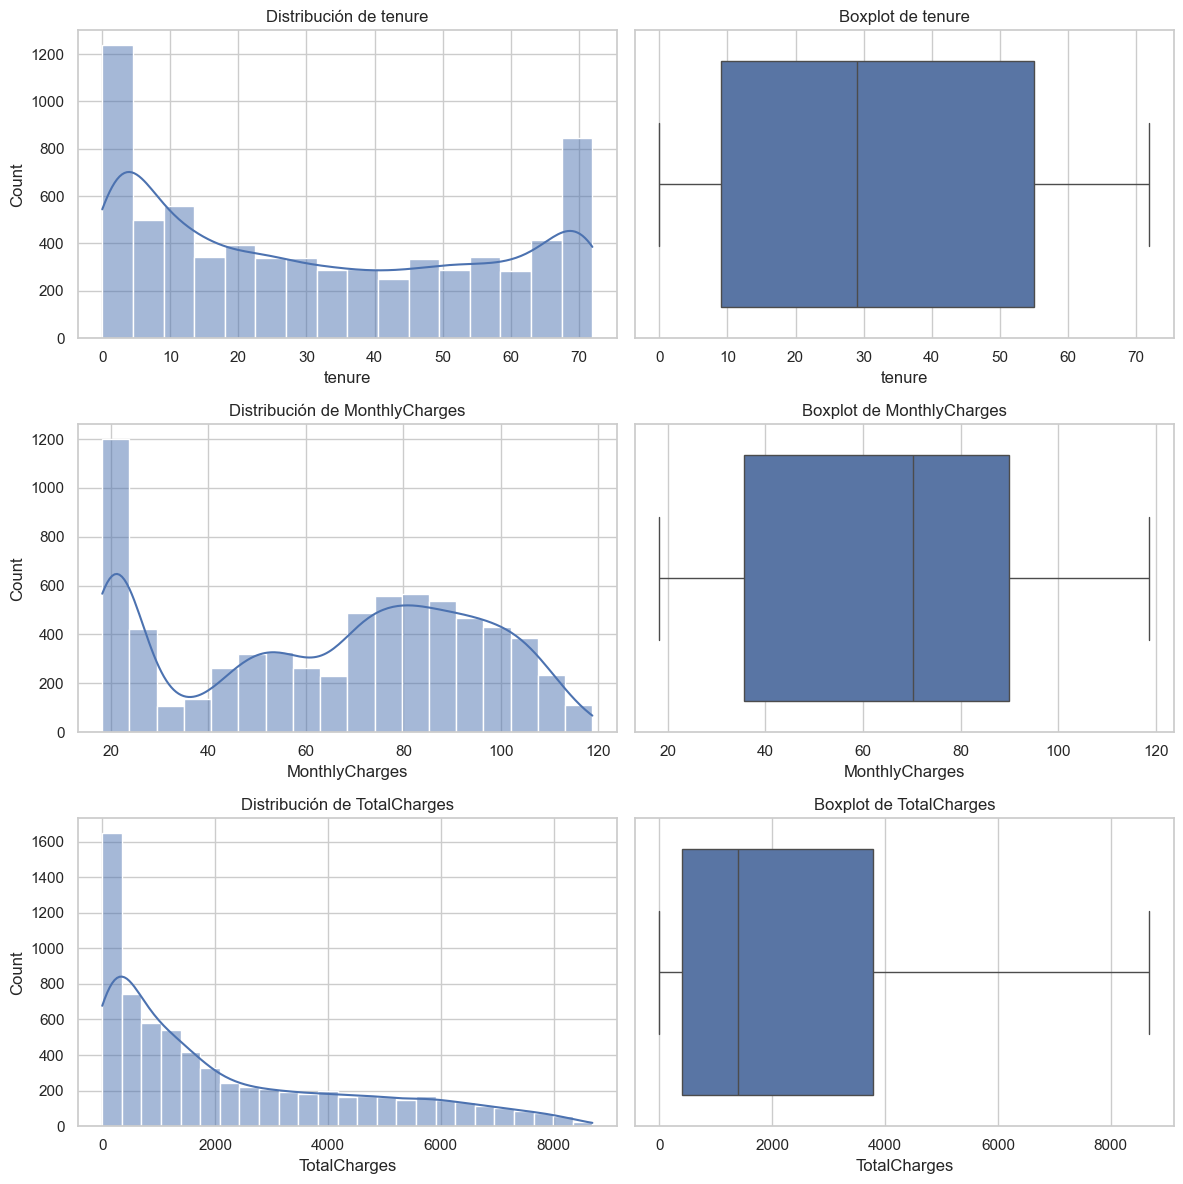

In [12]:
fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(12, 4 * len(numeric_cols)))

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f"Distribución de {col}")

    sns.boxplot(x=df[col], ax=axes[i, 1])
    axes[i, 1].set_title(f"Boxplot de {col}")

plt.tight_layout()
plt.show()

### 5.2 Distribución de variables categóricas

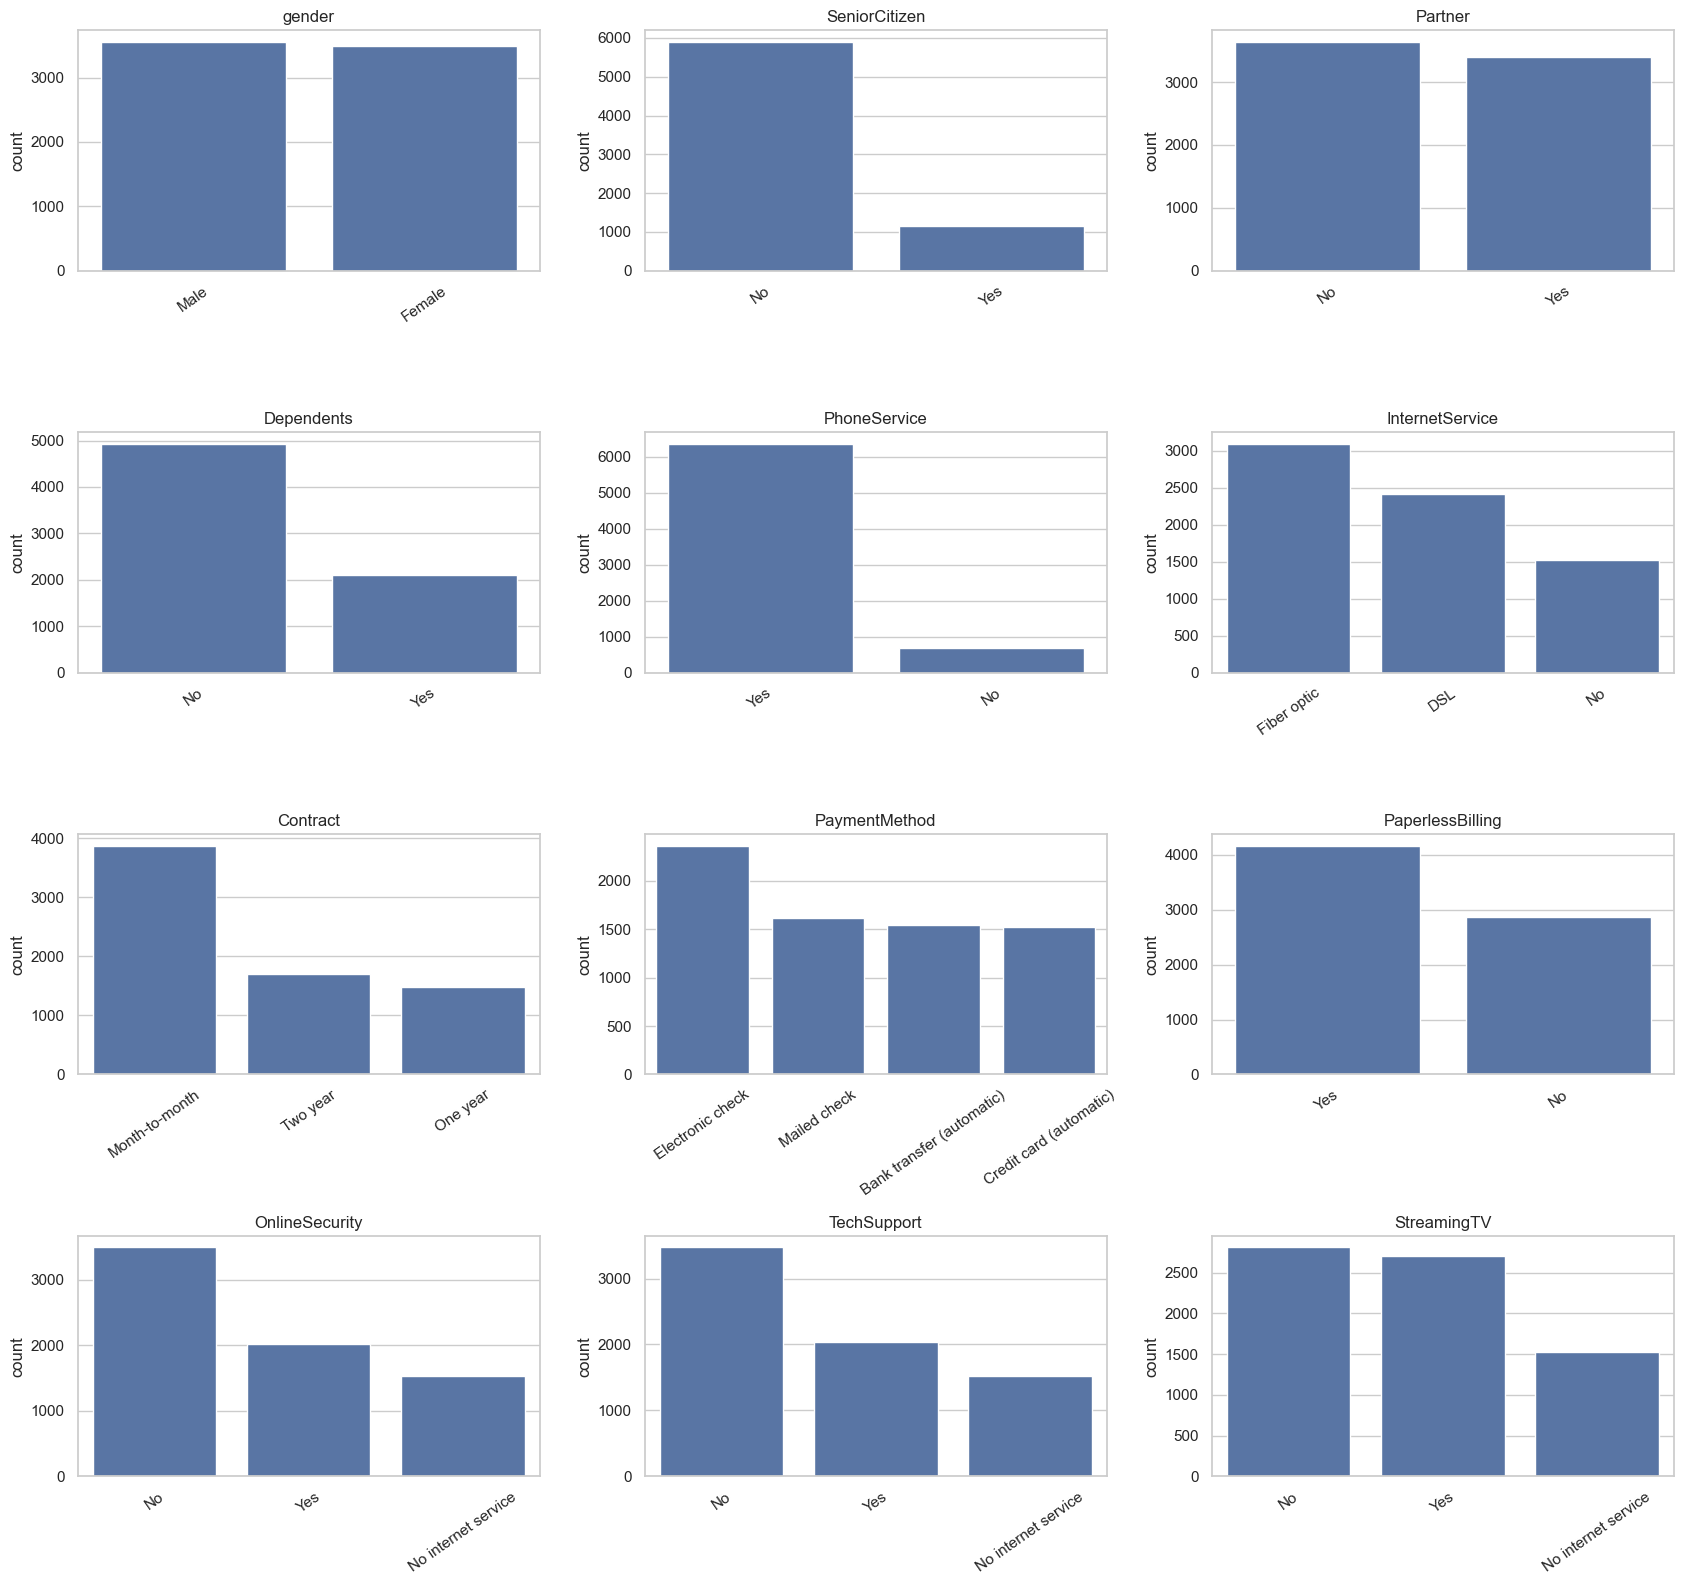

In [13]:
cols_to_plot = ["gender", "SeniorCitizen", "Partner", "Dependents",
    "PhoneService", "InternetService", "Contract", "PaymentMethod",
    "PaperlessBilling", "OnlineSecurity", "TechSupport", "StreamingTV"]

ncols = 3
nrows = int(np.ceil(len(cols_to_plot) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(17, 4 * nrows))
axes = axes.ravel()

for ax, col in zip(axes, cols_to_plot):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=35)
    ax.set_xlabel("")

for ax in axes[len(cols_to_plot):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

### 5.3 Distribución de la variable objetivo

En clasificación es importante inspeccionar el balance de las clases. Un desbalance puede hacer que accuracy resulte insuficiente como única medida de desempeño.

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Proporciones:


,proporción
Churn,
No,0.73463
Yes,0.26537


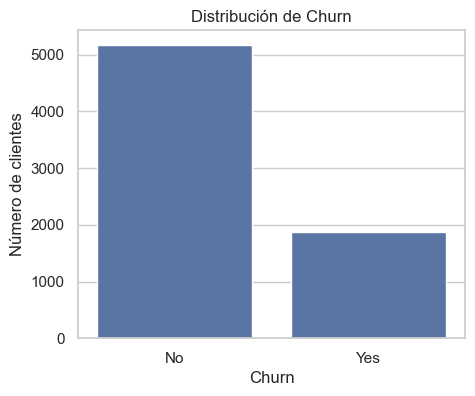

In [13]:
print(df[TARGET].value_counts())
print("\nProporciones:")
display(df[TARGET].value_counts(normalize=True).rename("proporción").to_frame())

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x=TARGET)
plt.title("Distribución de Churn")
plt.xlabel("Churn")
plt.ylabel("Número de clientes")
plt.show()

### 5.4 Correlación entre variables numéricas

Se utiliza correlación de Spearman porque no exige una relación lineal estricta y es adecuada para explorar relaciones monótonas.

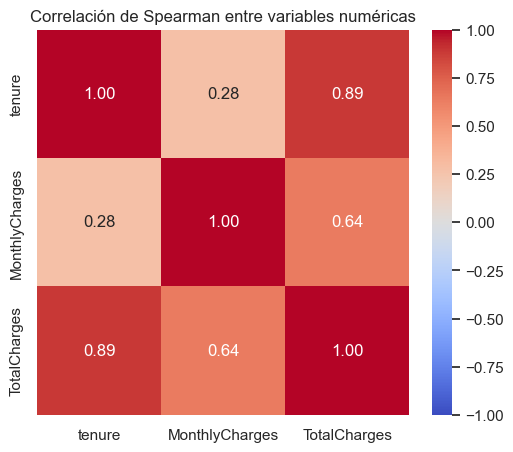

In [14]:
corr_num = df[numeric_cols].corr(method="spearman")

plt.figure(figsize=(6, 5))
sns.heatmap(corr_num, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlación de Spearman entre variables numéricas")
plt.show()

Las variables `Tenuere` y `TotalCharges` son las correlacionadas de acuerdo con el mapa de calor. Este valor de `0.89` no necesariamente significa que haya información redundante y deba eliminarse una de las dos variables. Se debe explorar en más detalle la posible dependencia entre estas dos variables.

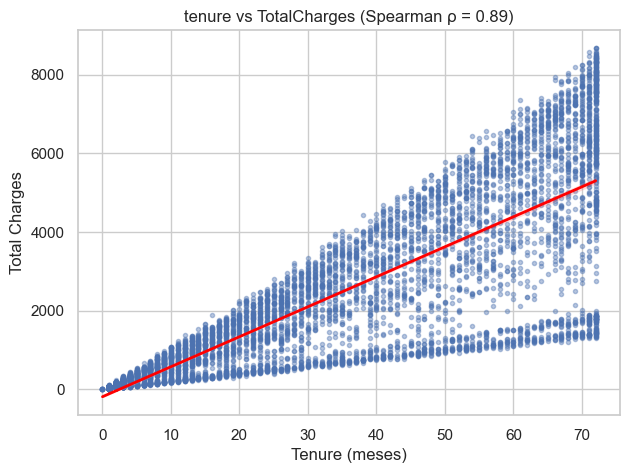

In [24]:
rho = corr_num.loc["tenure", "TotalCharges"]

plt.figure(figsize=(7, 5))

sns.regplot(data=df, x="tenure", y="TotalCharges", marker=".", scatter_kws={"alpha": 0.4},
    line_kws={"color": "red", "linewidth": 2.0})

plt.title(f"tenure vs TotalCharges (Spearman ρ = {rho:.2f})")
plt.xlabel("Tenure (meses)")
plt.ylabel("Total Charges")

plt.show()

### 5.5 Asociación entre variables categóricas con V de Cramér

La V de Cramér toma valores entre 0 y 1. Valores más altos indican una asociación más fuerte entre dos variables categóricas.

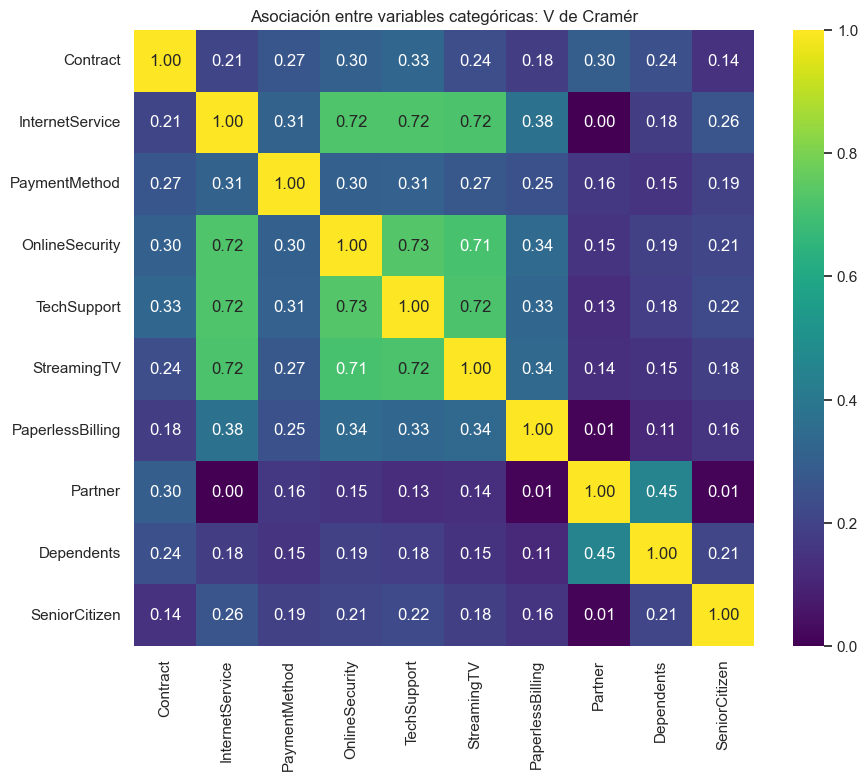

In [25]:
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.to_numpy().sum()
    r, k = table.shape

    if n <= 1 or min(r - 1, k - 1) == 0:
        return 0.0

    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denom = min(kcorr - 1, rcorr - 1)

    return np.sqrt(phi2corr / denom) if denom > 0 else 0.0

cat_for_assoc = ["Contract", "InternetService", "PaymentMethod", "OnlineSecurity",
    "TechSupport", "StreamingTV", "PaperlessBilling", "Partner", "Dependents", "SeniorCitizen"]

cramer = pd.DataFrame(index=cat_for_assoc, columns=cat_for_assoc, dtype=float)

for a in cat_for_assoc:
    for b in cat_for_assoc:
        cramer.loc[a, b] = cramers_v(df[a], df[b])

plt.figure(figsize=(10, 8))
sns.heatmap(cramer, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1)
plt.title("Asociación entre variables categóricas: V de Cramér")
plt.show()

El análisis mediante V de Cramér muestra asociaciones fuertes entre `InternetService`, `OnlineSecurity`, `TechSupport` y `StreamingTV`, con valores alrededor de `0.71–0.73`. Sin embargo, estas asociaciones deben interpretarse considerando la estructura del dataset, ya que los clientes sin servicio de Internet reciben categorías como “No internet service” en varias de estas variables. Por tanto, parte de la alta asociación se debe a una dependencia lógica entre los servicios. Fuera de este grupo, destaca la asociación moderada entre Partner y Dependents $(V = 0.45)$, mientras que muchas otras parejas de variables presentan asociaciones débiles o prácticamente nulas.